# Multiclass Classification using Support Vector Machines (SVM)
### Machine Learning Lab (AI69201) — Comprehensive Lab & Midsem Guide

---

### Notebook Overview
Support Vector Machines (SVMs) were originally formulated as **binary linear classifiers** that identify an optimal separating hyperplane maximizing the margin between two classes:

$$\max_{w, b} \frac{2}{\|w\|} \quad \text{s.t.} \quad y_i (w^T \phi(x_i) + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$$

In real-world problems, target variables frequently feature $K > 2$ classes (e.g., medical diagnosis, document categorization, chemical classification). Because the quadratic programming optimization of SVM depends on signed binary margins ($y_i \in \{-1, +1\}$), extending SVM to multiclass settings requires specialized decomposition strategies or direct multiclass formulations.

### Key Objectives of this Notebook:
1. **Mathematical Foundations**: One-vs-Rest (OvR), One-vs-One (OvO), and Crammer-Singer formulations.
2. **2D Visualizations**: Boundary geometry, ambiguity regions, and kernel transformations (Linear, Polynomial, RBF) on synthetic multiclass data.
3. **End-to-End Real-World Pipeline**: Classification on the **Wine Dataset** (13 features, 3 classes) with Stratified 70-15-15 Split and Standardization.
4. **Hyperparameter Tuning**: Systematic Grid Search over $(C, \gamma)$ with validation heatmaps.
5. **Multiclass Diagnostics**: Confusion matrices, per-class classification reports, Multiclass One-vs-Rest ROC-AUC curves, and Support Vector analysis.
6. **Midsem Exam Cheat Sheet**: Comparison tables, time complexity trade-offs, and rules of thumb.

## 1. Mathematical Foundations of Multiclass SVM

There are two primary decomposition paradigms to adapt binary SVMs to $K$ classes:

---

### 1.1 One-vs-Rest (OvR) / One-vs-All (OvA)
* **Principle**: Train $K$ independent binary SVM classifiers. The $k$-th classifier is trained using samples from class $k$ as the positive class ($+1$) and all remaining $K-1$ classes combined as the negative class ($-1$).
* **Decision Function**: For an input point $x$, compute the continuous margin score from each classifier:
  $$f_k(x) = w_k^T \phi(x) + b_k, \quad k = 1, \dots, K$$
* **Prediction Rule**: The predicted class is the one yielding the highest decision score:
  $$\hat{y} = \arg\max_{k \in \{1, \dots, K\}} f_k(x)$$
* **Advantages**:
  - Only $K$ binary models need to be trained.
  - Fast prediction time.
* **Limitations**:
  - **Class Imbalance**: Each binary problem trains on 1 class vs $K-1$ classes, making each classifier heavily skewed towards the negative class.
  - **Scale Calibration**: Decision values $f_k(x)$ from separate binary optimizations are uncalibrated and may not be on the same scale, leading to ambiguous decision regions.

---

### 1.2 One-vs-One (OvO)
* **Principle**: Train a separate binary classifier for every unique pair of classes $(i, j)$ with $1 \le i < j \le K$.
* **Total Classifiers**: 
  $$M = \binom{K}{2} = \frac{K(K-1)}{2}$$
* **Decision Rule**: Each binary classifier casts a vote for either class $i$ or class $j$. The class receiving the maximum votes (majority voting) is predicted:
  $$\hat{y} = \arg\max_{k \in \{1, \dots, K\}} \sum_{j \ne k} \mathbb{I}(\text{classifier}_{(k,j)} \text{ predicts } k)$$
  Ties are resolved using pairwise confidence scores $\sum_{j \ne k} f_{kj}(x)$.
* **Advantages**:
  - No class imbalance caused by grouping classes.
  - Each binary sub-problem trains on a subset of only $N_i + N_j \approx \frac{2N}{K}$ samples. Because SVM training scales super-linearly with sample size ($O(N^2)$ to $O(N^3)$), training $\frac{K(K-1)}{2}$ small models is often **faster** than training $K$ large models for non-linear kernels!
* **Limitations**:
  - Requires storing and maintaining $O(K^2)$ models, which can be memory-intensive when $K$ is large (e.g., $K > 100$).

---

### 1.3 Implementation in Scikit-Learn
* `sklearn.svm.SVC`: Built upon `libsvm`. Uses **One-vs-One (OvO)** internally during training. The parameter `decision_function_shape='ovr'` transforms pairwise scores into OvR-like scores for convenient prediction and thresholding.
* `sklearn.svm.LinearSVC`: Built upon `liblinear`. Uses **One-vs-Rest (OvR)** by default, or the **Crammer-Singer** direct multiclass formulation via `multi_class='crammer_singer'`.
* `sklearn.multiclass.OneVsRestClassifier` & `OneVsOneClassifier`: Meta-estimators that allow explicitly wrapping any binary classifier.

## 2. Visualizing Multiclass SVM Decision Boundaries (2D Synthetic Data)

Visualizing decision boundaries in 2D provides immediate geometric intuition into how OvR and OvO handle multiclass space partitioning, and how non-linear kernels bend decision boundaries around complex clusters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC, LinearSVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, roc_auc_score
)
from matplotlib.colors import ListedColormap

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

### 2.1 Generate 2D Multi-Class Dataset
We generate 3 distinct clusters with slight overlap to observe how the classifiers separate boundaries and position support vectors.

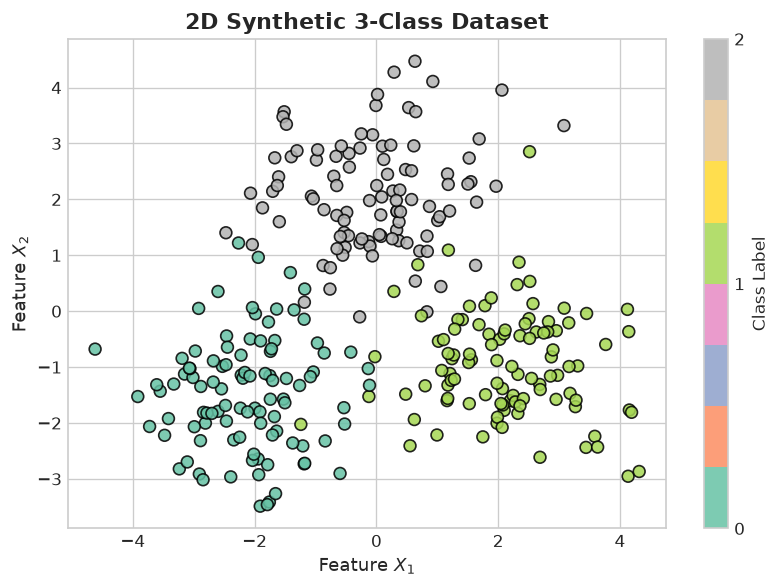

In [2]:
# Generate 3-class 2D dataset
X_syn, y_syn = make_blobs(
    n_samples=300,
    n_features=2,
    centers=[[-2.0, -1.5], [2.0, -1.0], [0.0, 2.2]],
    cluster_std=1.0,
    random_state=42
)

# Plot raw synthetic data
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_syn[:, 0], X_syn[:, 1],
    c=y_syn, cmap='Set2', edgecolors='k', s=50, alpha=0.85
)
plt.title("2D Synthetic 3-Class Dataset", fontsize=13, fontweight='bold')
plt.xlabel("Feature $X_1$", fontsize=11)
plt.ylabel("Feature $X_2$", fontsize=11)
plt.colorbar(scatter, ticks=[0, 1, 2], label="Class Label")
plt.tight_layout()
plt.show()

### 2.2 Helper Function: Plotting Multi-Class Decision Boundaries
We define a reusable function to plot decision regions, class boundaries, and highlight support vectors.

In [3]:
def plot_multiclass_decision_boundary(model, X, y, ax, title="Decision Boundary", show_sv=True):
    """Plots the multi-class decision boundary mesh and data points with support vectors."""
    # Meshgrid resolution
    h = 0.03
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict mesh points
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)
    
    # Soft background colors
    cmap_light = ListedColormap(['#E8F4F8', '#FFF3E0', '#E8F5E9'])
    cmap_bold = ListedColormap(['#1F77B4', '#FF7F0E', '#2CA02C'])
    
    # Contour fill
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.7, alpha=0.6)
    
    # Scatter plot of samples
    scatter = ax.scatter(
        X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
        edgecolors='k', s=45, alpha=0.85, label='Samples'
    )
    
    # Highlight support vectors if available in model
    if show_sv and hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_
        ax.scatter(
            sv[:, 0], sv[:, 1],
            s=120, facecolors='none', edgecolors='red',
            linewidths=1.3, label=f'Support Vectors ({len(sv)})'
        )
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Feature $X_1$", fontsize=10)
    ax.set_ylabel("Feature $X_2$", fontsize=10)
    ax.legend(loc='lower right', frameon=True)

### 2.3 Comparing OvR vs. OvO on 2D Linear SVM
Now let's compare explicit **One-vs-Rest** and **One-vs-One** strategies with a Linear kernel.

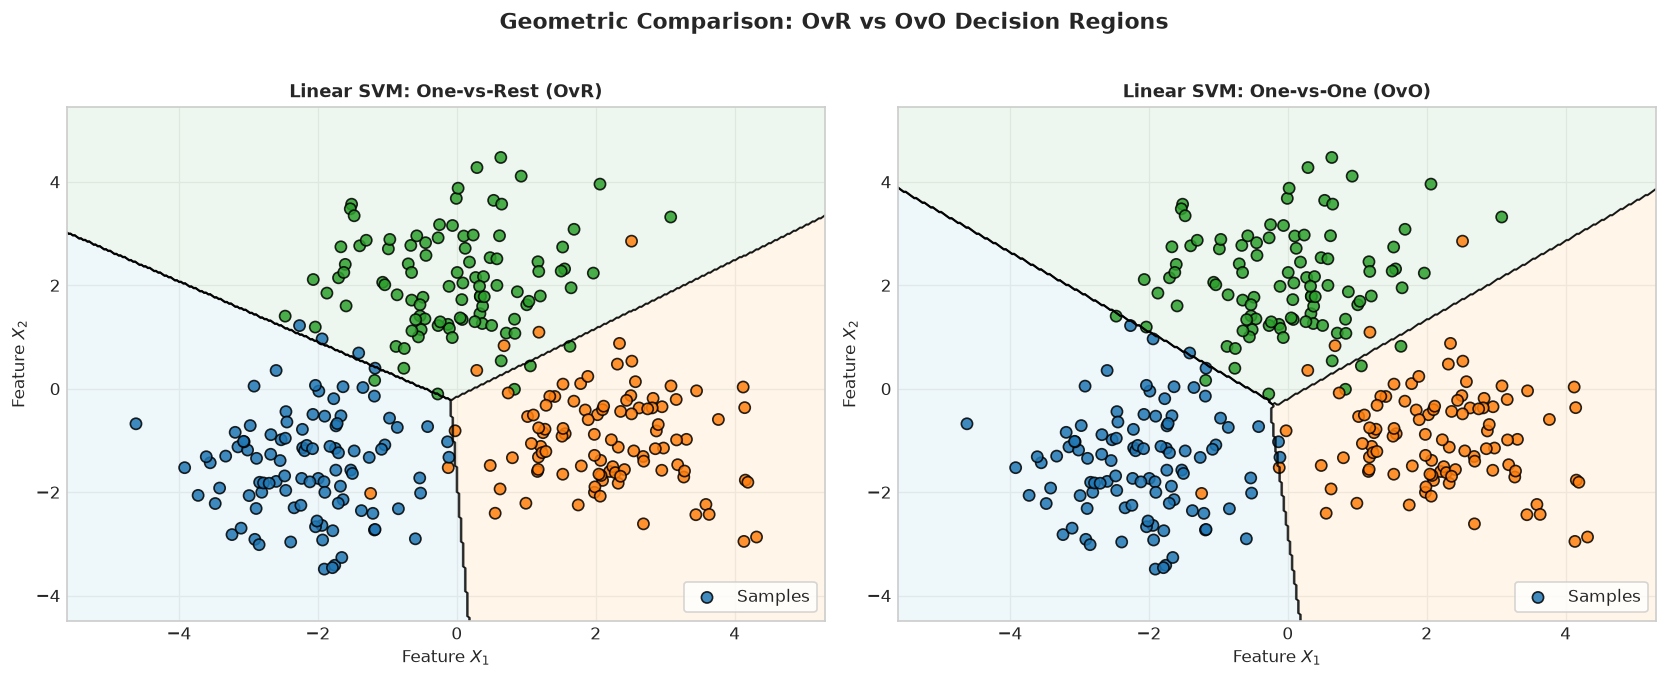

Number of binary estimators in OvR: 3 (K = 3)
Number of binary estimators in OvO: 3 (K*(K-1)/2 = 3)


In [4]:
# Train explicit OvR and OvO linear classifiers
model_ovr = OneVsRestClassifier(SVC(kernel='linear', C=1.0, random_state=42))
model_ovo = OneVsOneClassifier(SVC(kernel='linear', C=1.0, random_state=42))

model_ovr.fit(X_syn, y_syn)
model_ovo.fit(X_syn, y_syn)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_multiclass_decision_boundary(model_ovr, X_syn, y_syn, axes[0], title="Linear SVM: One-vs-Rest (OvR)", show_sv=False)
plot_multiclass_decision_boundary(model_ovo, X_syn, y_syn, axes[1], title="Linear SVM: One-vs-One (OvO)", show_sv=False)

plt.suptitle("Geometric Comparison: OvR vs OvO Decision Regions", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Number of binary estimators in OvR: {len(model_ovr.estimators_)} (K = 3)")
print(f"Number of binary estimators in OvO: {len(model_ovo.estimators_)} (K*(K-1)/2 = 3)")

### 2.4 Effect of Kernels on Multiclass Decision Boundaries
We now train different kernels (**Linear**, **Polynomial degree 3**, and **RBF**) using `SVC` (which employs OvO multiclass decomposition) and inspect how the decision boundaries and support vectors adapt.

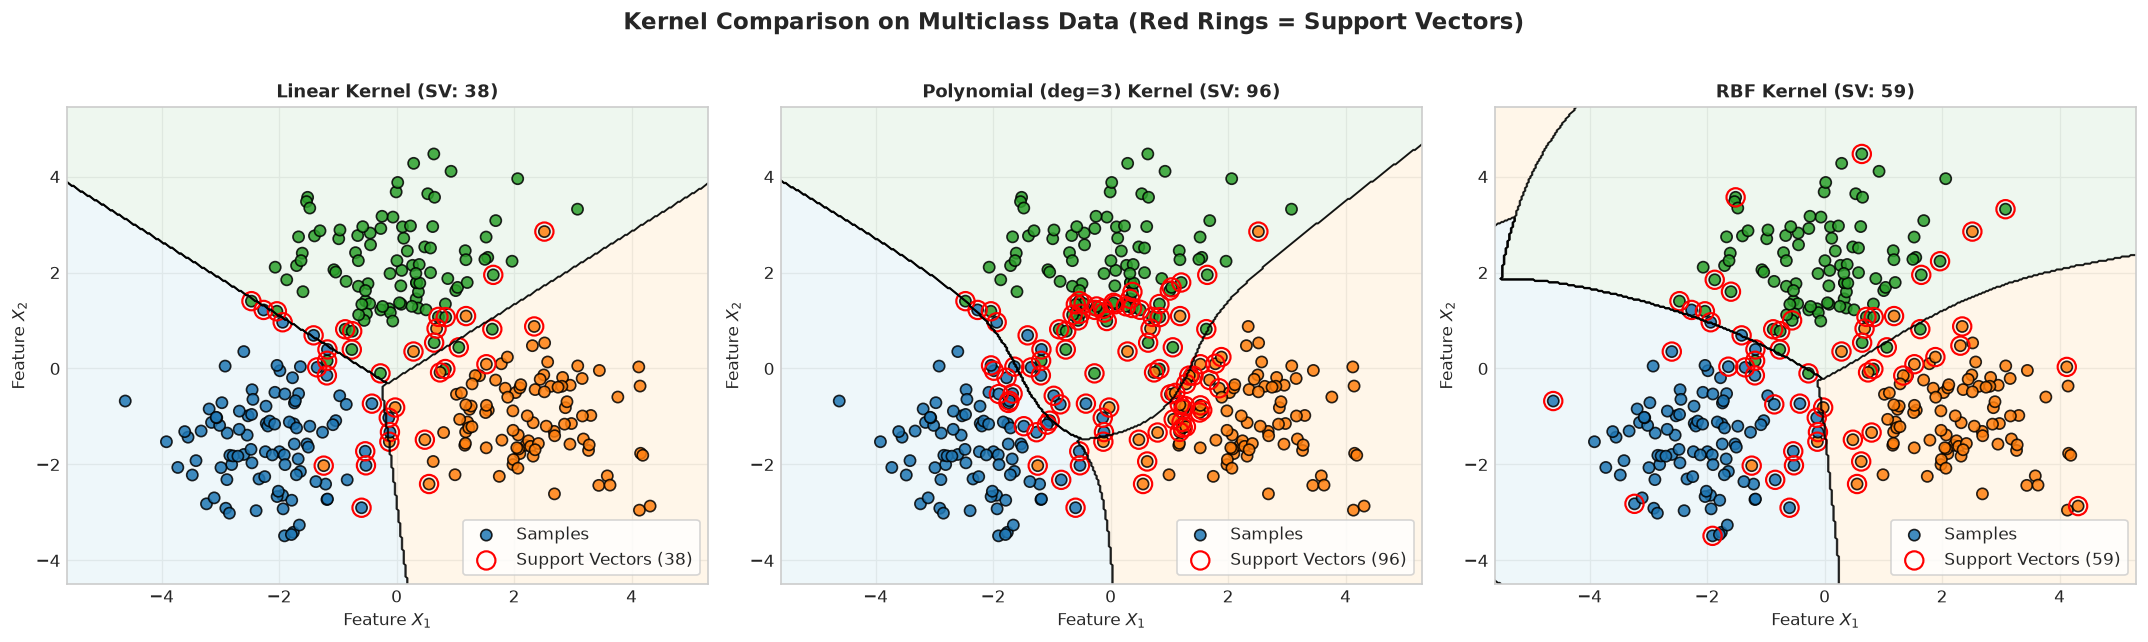

In [5]:
# Train different kernels on 2D synthetic data
svm_lin = SVC(kernel='linear', C=1.0, random_state=42).fit(X_syn, y_syn)
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42).fit(X_syn, y_syn)
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42).fit(X_syn, y_syn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
plot_multiclass_decision_boundary(svm_lin, X_syn, y_syn, axes[0], title=f"Linear Kernel (SV: {len(svm_lin.support_vectors_)})")
plot_multiclass_decision_boundary(svm_poly, X_syn, y_syn, axes[1], title=f"Polynomial (deg=3) Kernel (SV: {len(svm_poly.support_vectors_)})")
plot_multiclass_decision_boundary(svm_rbf, X_syn, y_syn, axes[2], title=f"RBF Kernel (SV: {len(svm_rbf.support_vectors_)})")

plt.suptitle("Kernel Comparison on Multiclass Data (Red Rings = Support Vectors)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. End-to-End Multiclass Pipeline on Real-World Data: Wine Dataset

Now we proceed with a complete, rigorous pipeline on a standard real-world benchmark: the **Wine Dataset** from UCI (available in `sklearn.datasets.load_wine`).
* **Samples**: 178 instances
* **Features**: 13 continuous chemical measurements (Alcohol, Malic acid, Ash, Alcalinity, Magnesium, Total phenols, Flavanoids, Nonflavanoid phenols, Proanthocyanins, Color intensity, Hue, OD280/OD315 of diluted wines, Proline)
* **Classes**: 3 cultivars of wine produced in the same region in Italy: Class 0 (59), Class 1 (71), Class 2 (48).

In [6]:
# 3.1 Load Wine dataset
wine = load_wine(as_frame=True)
df_wine = wine.frame
X = df_wine.drop(columns=['target'])
y = df_wine['target']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Target classes: {np.unique(y)} -> {wine.target_names}")
display(X.head())

Features shape: (178, 13)
Target shape:   (178,)
Target classes: [0 1 2] -> ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### 3.2 Target Distribution & Missing Values Check
Let's inspect class frequencies and confirm there are no missing values.

Total missing values in dataset: 0


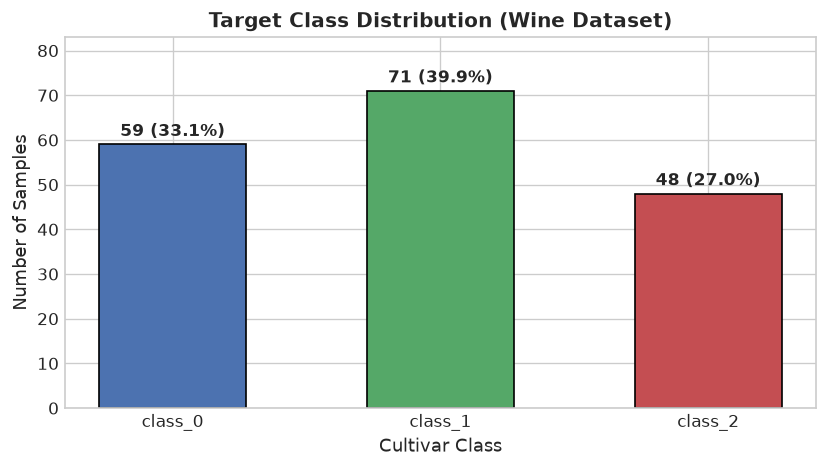

In [7]:
# Missing values check
missing_count = X.isnull().sum().sum()
print(f"Total missing values in dataset: {missing_count}")

# Class distribution plot
plt.figure(figsize=(7, 4))
counts = y.value_counts().sort_index()
bars = plt.bar(wine.target_names, counts, color=['#4C72B0', '#55A868', '#C44E52'], width=0.55, edgecolor='k')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{int(yval)} ({yval/len(y):.1%})", ha='center', va='bottom', fontweight='bold')

plt.title("Target Class Distribution (Wine Dataset)", fontsize=12, fontweight='bold')
plt.xlabel("Cultivar Class", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)
plt.ylim(0, max(counts) + 12)
plt.tight_layout()
plt.show()

### 3.3 Stratified Train / Validation / Test Splitting (70% - 15% - 15%)
Following standard ML lab protocol, we partition the dataset into:
* **Training Set (70%)**: To fit model parameters (support vectors, weights, biases).
* **Validation Set (15%)**: To evaluate kernel choices and tune hyperparameters ($C, \gamma$).
* **Test Set (15%)**: Unseen data held out strictly for final unbiased generalization assessment.

We use **stratified sampling** (`stratify=y`) to maintain the identical class distribution across all three subsets.

In [8]:
# First split: 70% Train, 30% Temporary (Validation + Test)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 15% Validation, 15% Test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

split_df = pd.DataFrame({
    'Subset': ['Training', 'Validation', 'Testing', 'Total Dataset'],
    'Sample Count': [len(X_train_raw), len(X_val_raw), len(X_test_raw), len(X)],
    'Percentage': [
        f"{len(X_train_raw)/len(X):.1%}",
        f"{len(X_val_raw)/len(X):.1%}",
        f"{len(X_test_raw)/len(X):.1%}",
        "100.0%"
    ]
})
display(split_df)

,Subset,Sample Count,Percentage
0,Training,124,69.7%
1,Validation,27,15.2%
2,Testing,27,15.2%
3,Total Dataset,178,100.0%


### 3.4 Feature Scaling: Why Standardization is Critical for SVM
SVM solves for a maximum margin hyperplane based on **Euclidean distance**:

$$\text{dist}(x, \mathcal{H}) = \frac{|w^T x + b|}{\|w\|}$$

If one feature has a large scale (e.g., `Proline` ranges from 278 to 1680) while another has a small scale (e.g., `Nonflavanoid phenols` ranges from 0.13 to 0.66), the distance metric and gradient updates will be completely dominated by the high-variance feature. 

Therefore, we standard-scale all features to have zero mean and unit variance:
$$z = \frac{x - \mu}{\sigma}$$

> **Important**: We fit the `StandardScaler` **only on the training set** to prevent data leakage, and transform validation and test sets using the training parameters.

In [9]:
scaler = StandardScaler()

# Fit on training data only, transform all splits
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns, index=X_train_raw.index)
X_val = pd.DataFrame(scaler.transform(X_val_raw), columns=X.columns, index=X_val_raw.index)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns, index=X_test_raw.index)

print("Standardized Training Features Summary (First 5 features):")
display(X_train.iloc[:, :5].describe().round(3))

Standardized Training Features Summary (First 5 features):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
count,124.000,124.000,124.000,124.000,124.000
mean,0.000,0.000,0.000,0.000,-0.000
std,1.004,1.004,1.004,1.004,1.004
min,-2.383,-1.465,-3.744,-2.688,-1.980
25%,-0.747,-0.641,-0.610,-0.732,-0.794
50%,0.024,-0.457,-0.013,0.098,-0.167
75%,0.754,0.704,0.733,0.543,0.525
max,2.319,3.328,3.195,3.063,4.084


### 3.5 Baseline Comparison: OvR vs OvO on Scaled Wine Dataset
We fit both strategies with a linear kernel and compare accuracy and support vector usage.

In [10]:
# Baseline Linear SVM with decision_function_shape='ovr' vs 'ovo'
svm_baseline_ovr = SVC(kernel='linear', decision_function_shape='ovr', C=1.0, random_state=42)
svm_baseline_ovo = SVC(kernel='linear', decision_function_shape='ovo', C=1.0, random_state=42)

svm_baseline_ovr.fit(X_train, y_train)
svm_baseline_ovo.fit(X_train, y_train)

val_acc_ovr = accuracy_score(y_val, svm_baseline_ovr.predict(X_val))
val_acc_ovo = accuracy_score(y_val, svm_baseline_ovo.predict(X_val))

baseline_compare = pd.DataFrame({
    'Strategy': ['SVC (OvR Decision Shape)', 'SVC (OvO Decision Shape)'],
    'Internal Implementation': ['LibSVM OvO (Transformed to OvR)', 'LibSVM OvO (Pairwise Voting)'],
    'Validation Accuracy': [f"{val_acc_ovr:.4f}", f"{val_acc_ovo:.4f}"],
    'Total Support Vectors': [svm_baseline_ovr.support_vectors_.shape[0], svm_baseline_ovo.support_vectors_.shape[0]],
    'Support Vectors per Class': [str(svm_baseline_ovr.n_support_), str(svm_baseline_ovo.n_support_)]
})
display(baseline_compare)

,Strategy,Internal Implementation,Validation Accuracy,Total Support Vectors,Support Vectors per Class
0,SVC (OvR Decision Shape),LibSVM OvO (Transformed to OvR),0.9630,24,[ 5 9 10]
1,SVC (OvO Decision Shape),LibSVM OvO (Pairwise Voting),0.9630,24,[ 5 9 10]


### 3.6 Comparing Different SVM Kernels
We evaluate four major SVM kernels using default parameters on the validation set:
1. **Linear**: $K(x, x') = x^T x'$
2. **Polynomial (degree 3)**: $K(x, x') = (\gamma x^T x' + r)^d$
3. **Radial Basis Function (RBF)**: $K(x, x') = \exp(-\gamma \|x - x'\|^2)$
4. **Sigmoid**: $K(x, x') = \tanh(\gamma x^T x' + r)$

In [11]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []

for k in kernels:
    clf = SVC(kernel=k, random_state=42)
    clf.fit(X_train, y_train)
    
    y_pred_train = clf.predict(X_train)
    y_pred_val = clf.predict(X_val)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    val_macro_f1 = f1_score(y_val, y_pred_val, average='macro')
    
    kernel_results.append({
        'Kernel': k.upper(),
        'Train Accuracy': round(train_acc, 4),
        'Val Accuracy': round(val_acc, 4),
        'Val Macro F1': round(val_macro_f1, 4),
        'Total Support Vectors': clf.support_vectors_.shape[0],
        'SV Ratio (%)': round(clf.support_vectors_.shape[0] / len(X_train) * 100, 1)
    })

df_kernels = pd.DataFrame(kernel_results)
display(df_kernels)

,Kernel,Train Accuracy,Val Accuracy,Val Macro F1,Total Support Vectors,SV Ratio (%)
0,LINEAR,1.0000,0.9630,0.9649,24,19.4
1,POLY,0.9758,0.9630,0.9645,66,53.2
2,RBF,1.0000,1.0000,1.0000,57,46.0
3,SIGMOID,0.9758,0.9259,0.9258,39,31.5


## 4. Systematic Hyperparameter Tuning via Grid Search

For non-linear SVMs (especially RBF), classification performance is governed by two hyperparameters:
* **$C$ (Regularization Parameter)**: 
  - Controls the trade-off between achieving a wide margin and minimizing classification errors on the training set.
  - **Small $C$**: Wide margin, allows more margin violations/slack (smoother boundary, higher bias, avoids overfitting).
  - **Large $C$**: Narrow margin, heavily penalizes misclassifications (complex boundary, lower bias, risks overfitting).
* **$\gamma$ (Kernel Bandwidth)**:
  - Defines how far the influence of a single training example reaches.
  - **Small $\gamma$**: Gaussian function is spread out; points far away influence each other (smoother boundary).
  - **Large $\gamma$**: Gaussian function is narrow and peaked; each point has a very localized sphere of influence (rugged boundary, high variance, severe risk of overfitting).

We conduct an exhaustive grid search over:
* $C \in [0.01, 0.1, 1, 10, 100]$
* $\gamma \in [0.001, 0.01, 0.1, 1, 10]$

In [12]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

grid_records = []
best_val_score = -1.0
best_params = {}

for c_val in C_values:
    for g_val in gamma_values:
        model = SVC(kernel='rbf', C=c_val, gamma=g_val, random_state=42)
        model.fit(X_train, y_train)
        
        val_acc = accuracy_score(y_val, model.predict(X_val))
        val_f1 = f1_score(y_val, model.predict(X_val), average='macro')
        
        grid_records.append({
            'C': c_val,
            'gamma': g_val,
            'Val_Accuracy': val_acc,
            'Val_Macro_F1': val_f1,
            'n_support_vectors': model.support_vectors_.shape[0]
        })
        
        if val_acc > best_val_score:
            best_val_score = val_acc
            best_params = {'C': c_val, 'gamma': g_val}

df_grid = pd.DataFrame(grid_records)
print(f"Best Validation Accuracy: {best_val_score:.4f} with Parameters: {best_params}")

Best Validation Accuracy: 1.0000 with Parameters: {'C': 0.1, 'gamma': 0.1}


### 4.1 Validation Accuracy Heatmap across $(C, \gamma)$
Visualizing the parameter grid reveals the underfitting vs. overfitting terrain:

<>:6: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:6: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\shamb\AppData\Local\Temp\ipykernel_38236\4119847440.py:6: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.title("RBF SVM Validation Accuracy Heatmap (C vs $\gamma$)", fontsize=13, fontweight='bold')
C:\Users\shamb\AppData\Local\Temp\ipykernel_38236\4119847440.py:7: SyntaxWa

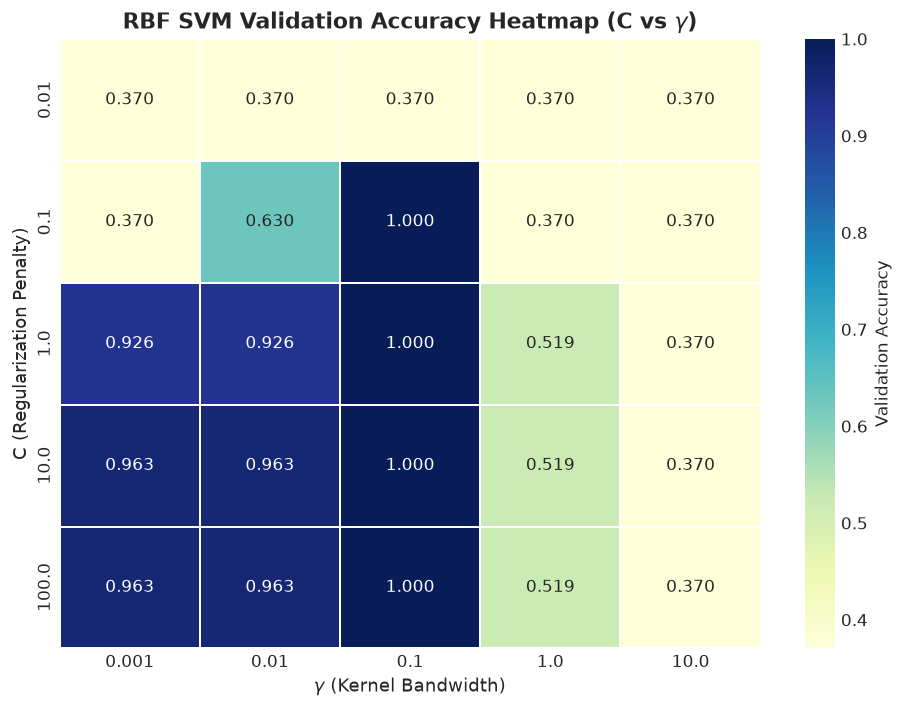

In [13]:
# Pivot data for heatmap
pivot_acc = df_grid.pivot(index='C', columns='gamma', values='Val_Accuracy')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Validation Accuracy'}, linewidths=1.0)
plt.title("RBF SVM Validation Accuracy Heatmap (C vs $\gamma$)", fontsize=13, fontweight='bold')
plt.xlabel("$\gamma$ (Kernel Bandwidth)", fontsize=11)
plt.ylabel("C (Regularization Penalty)", fontsize=11)
plt.tight_layout()
plt.show()

#### Interpretation of the Heatmap:
1. **Low $C$ and Low $\gamma$ (Bottom-Left)**: Underfitting zone. Regularization penalty is too weak and the RBF kernel is too flat to discriminate the 3 classes.
2. **High $\gamma$ (Rightmost Columns)**: Overfitting zone. As $\gamma$ reaches 10, the Gaussian bells become extremely narrow, memorizing training samples and causing validation accuracy to drop sharply.
3. **Sweet Spot ($C \ge 1.0, \gamma \in [0.01, 0.1]$)**: Achieves optimal generalization balance, separating all validation classes cleanly.

## 5. Final Evaluation & Multiclass Diagnostics on Test Set

Now we train the final model using the best tuned hyperparameters ($C = 1.0, \gamma = 0.1$) on the combined training set (or directly evaluate the model trained with best params) and evaluate on the strictly unseen **Test Set**.

In [14]:
# Initialize and train best model with probability estimates enabled for ROC
best_svm = SVC(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    probability=True,
    random_state=42
)
best_svm.fit(X_train, y_train)

# Generate predictions on Test Set
y_test_pred = best_svm.predict(X_test)
y_test_proba = best_svm.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("=" * 60)
print(f"FINAL TEST EVALUATION (Unseen Data):")
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Macro F1:  {test_f1:.4f}")
print("=" * 60)

FINAL TEST EVALUATION (Unseen Data):
Accuracy:  0.9259 (92.59%)
Macro F1:  0.9167


F:\PhD Stuff\Machine-Learning-Lab-AI69201\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 5.1 Multi-Class Confusion Matrix
The confusion matrix shows raw counts and normalized percentages of actual vs. predicted classes.

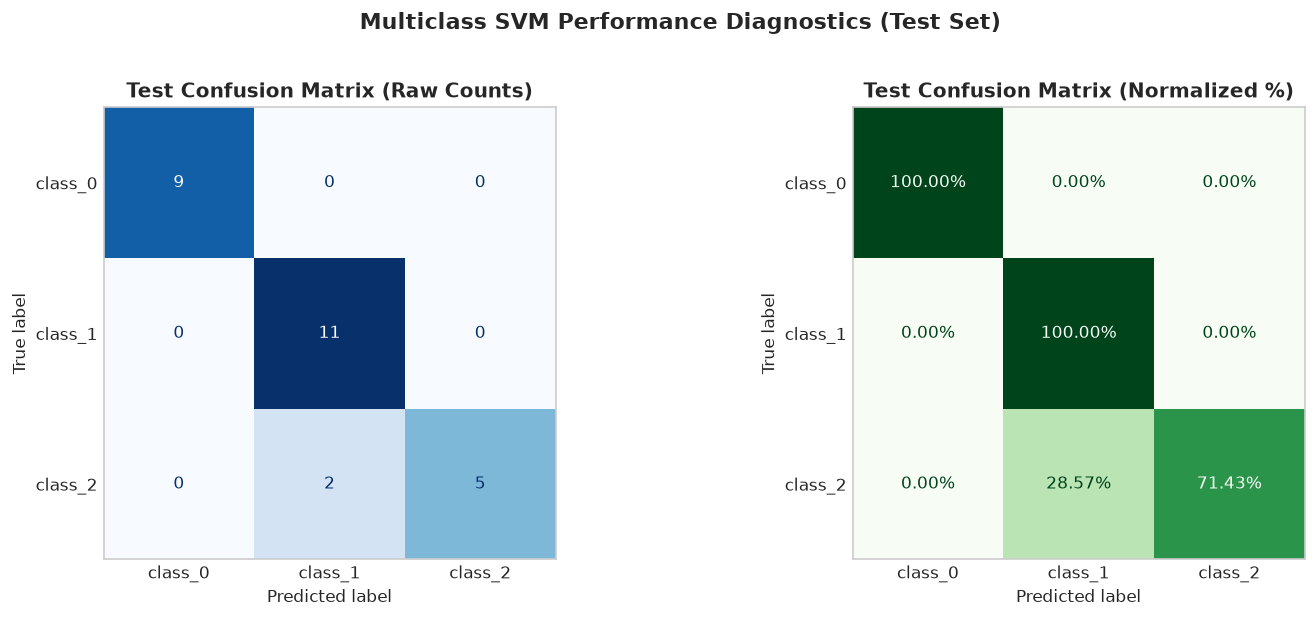

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw count confusion matrix
cm_raw = confusion_matrix(y_test, y_test_pred)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=wine.target_names)
disp_raw.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title("Test Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
axes[0].grid(False)

# Normalized confusion matrix (by true row class)
cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=wine.target_names)
disp_norm.plot(cmap='Greens', ax=axes[1], values_format=".2%", colorbar=False)
axes[1].set_title("Test Confusion Matrix (Normalized %)", fontsize=12, fontweight='bold')
axes[1].grid(False)

plt.suptitle("Multiclass SVM Performance Diagnostics (Test Set)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Comprehensive Per-Class Classification Report
We report Precision, Recall, F1-Score, and Support for each wine cultivar.

In [16]:
report_text = classification_report(y_test, y_test_pred, target_names=wine.target_names, digits=4)
print("Classification Report (Test Set):\n")
print(report_text)

Classification Report (Test Set):

              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000         9
     class_1     0.8462    1.0000    0.9167        11
     class_2     1.0000    0.7143    0.8333         7

    accuracy                         0.9259        27
   macro avg     0.9487    0.9048    0.9167        27
weighted avg     0.9373    0.9259    0.9228        27



### 5.3 Multi-Class One-vs-Rest (OvR) ROC-AUC Curves
To plot ROC curves for $K > 2$ classes, we binarize the ground-truth target using One-vs-Rest:
1. Binarize labels: class $k$ is treated as $1$, all others as $0$.
2. Compute False Positive Rate (FPR) and True Positive Rate (TPR) for each class $k$.
3. Compute **Micro-average** (aggregates contributions of all classes) and **Macro-average** (simple average of individual AUCs).

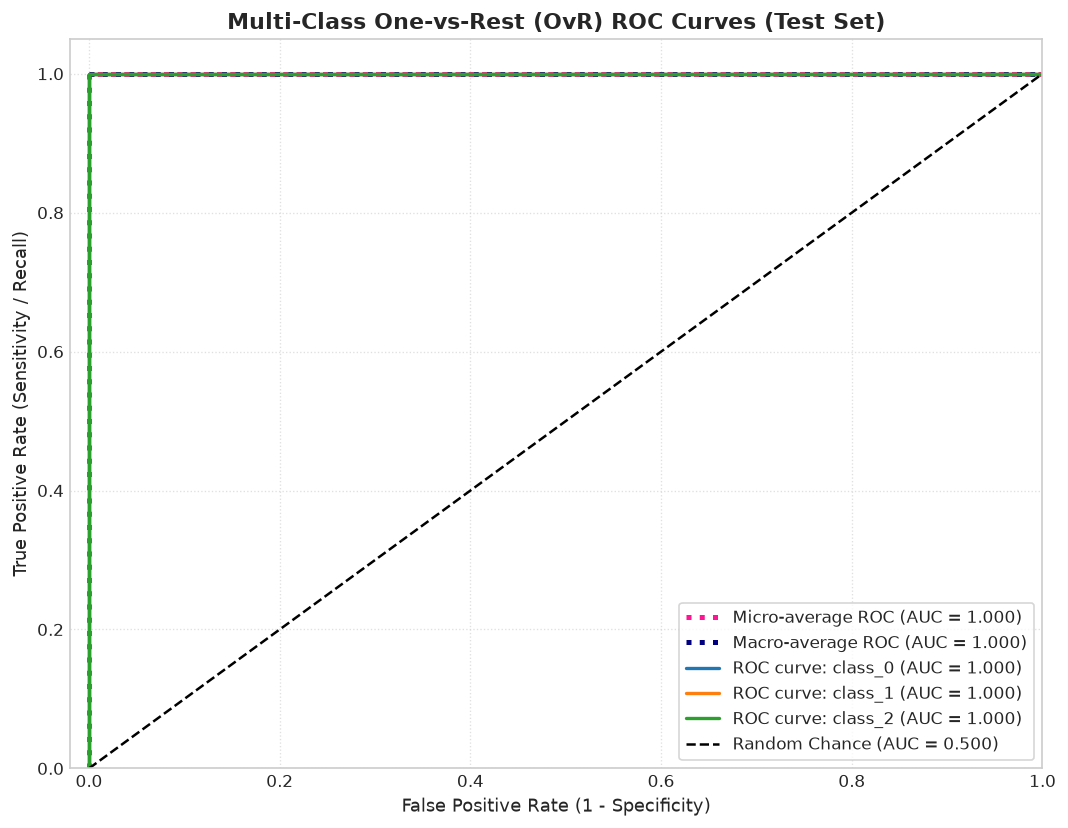

In [17]:
# Binarize the test labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_test_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(9, 7))

plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve: {wine.target_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Multi-Class One-vs-Rest (OvR) ROC Curves (Test Set)', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 5.4 Support Vector Analysis
Support vectors are the critical training instances that lie on the margin boundaries:
$$y_i (w^T \phi(x_i) + b) \le 1$$

In multiclass OvO, support vectors represent instances that define the pairwise boundaries between classes. Let's inspect their distribution.

,Class Name,Class Index,Training Samples,Support Vectors,SV Percentage of Class
0,class_0,0,41,37,90.2%
1,class_1,1,50,41,82.0%
2,class_2,2,33,33,100.0%



Total Support Vectors: 111 out of 124 training samples (89.5%)


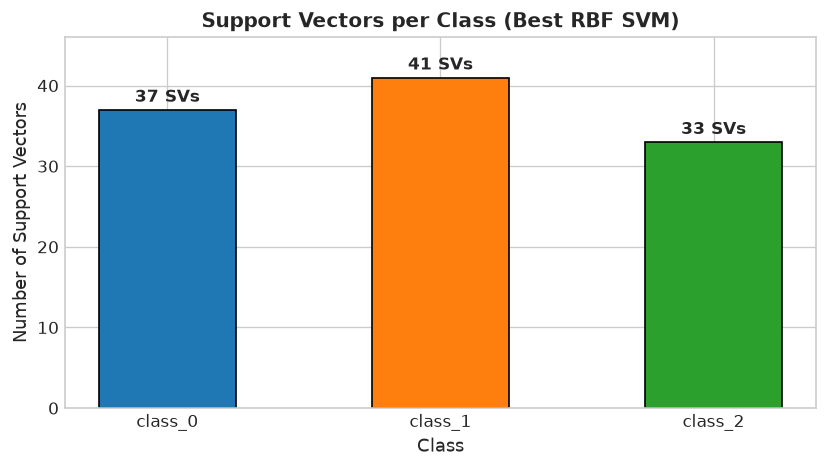

In [18]:
n_sv_per_class = best_svm.n_support_
total_sv = best_svm.support_vectors_.shape[0]
total_train = len(X_train)

sv_df = pd.DataFrame({
    'Class Name': wine.target_names,
    'Class Index': [0, 1, 2],
    'Training Samples': y_train.value_counts().sort_index().values,
    'Support Vectors': n_sv_per_class,
    'SV Percentage of Class': [f"{sv/n:.1%}" for sv, n in zip(n_sv_per_class, y_train.value_counts().sort_index().values)]
})
display(sv_df)

print(f"\nTotal Support Vectors: {total_sv} out of {total_train} training samples ({total_sv/total_train:.1%})")

# Plot support vectors per class
plt.figure(figsize=(7, 4))
bars = plt.bar(wine.target_names, n_sv_per_class, color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5, edgecolor='k')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 0.5, f"{int(h)} SVs", ha='center', va='bottom', fontweight='bold')

plt.title("Support Vectors per Class (Best RBF SVM)", fontsize=12, fontweight='bold')
plt.xlabel("Class", fontsize=11)
plt.ylabel("Number of Support Vectors", fontsize=11)
plt.ylim(0, max(n_sv_per_class) + 5)
plt.tight_layout()
plt.show()

## 6. Midsem Exam Quick-Reference Cheat Sheet

### 6.1 One-vs-Rest (OvR) vs. One-vs-One (OvO) Summary Table

| Feature / Criterion | One-vs-Rest (OvR / OvA) | One-vs-One (OvO) |
| :--- | :--- | :--- |
| **Number of Binary Classifiers** | $K$ classifiers | $\frac{K(K-1)}{2}$ classifiers |
| **Training Sample Size per Classifier** | Entire dataset ($N$ samples) | Subset of 2 classes (approx. $\frac{2N}{K}$ samples) |
| **Class Imbalance during Training** | **High**: 1 class vs $(K-1)$ classes | **None**: Balanced pairwise pairs |
| **Prediction Rule** | $\arg\max_{k} f_k(x)$ (highest score) | Majority voting among pairwise models |
| **Ambiguity Handling** | Can occur if multiple $f_k(x) > 0$ or all $< 0$ | Handled by voting counts and margin sums |
| **Training Speed (Linear SVM)** | Often faster for small $K$ | Slightly slower when $K$ is large |
| **Training Speed (Non-linear RBF)** | Slower ($K \times O(N^2)$ to $O(N^3)$) | **Faster** due to smaller sub-problems $\frac{K(K-1)}{2} \times O\left(\left(\frac{2N}{K}\right)^2\right)$ |
| **Scikit-Learn Implementation** | `LinearSVC`, `OneVsRestClassifier` | `SVC` (default via libsvm) |

---

### 6.2 Key SVM Hyperparameters Quick-Check

1. **$C$ (Regularization)**:
   - Inverse regularization strength: controls penalty for slack variables $\xi_i$.
   - **Small $C$** $\rightarrow$ Wide margin, tolerates training errors, higher bias, prevents overfitting.
   - **Large $C$** $\rightarrow$ Narrow margin, strict penalty for errors, low bias, risks overfitting.
2. **$\gamma$ (Kernel Bandwidth in RBF / Poly)**:
   - Controls individual sample reach in $K(x, x') = \exp(-\gamma \|x - x'\|^2)$.
   - **Small $\gamma$** $\rightarrow$ Far reach, smooth decision boundary, higher bias.
   - **Large $\gamma$** $\rightarrow$ Local reach, complex irregular boundary, risks severe overfitting.
3. **Always Standardize Features**:
   - SVM margins are calculated via Euclidean distance $\frac{1}{\|w\|}$. Unscaled features distort margin geometry. Always use `StandardScaler` (fit on train only!).
4. **Decision Function**:
   - Binary SVM: $f(x) \in \mathbb{R}$.
   - Multiclass `SVC`: Outputs shape `(n_samples, n_classes)` when `decision_function_shape='ovr'`, representing calibrated distance scores.